# Wind Power Generation Prediction

---

---
## 0. Install & Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import shap

---
## 1. Data Loading & Exploration

In [2]:
df = pd.read_csv('T1.csv')
df.head()

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


In [3]:
print('Shape:', df.shape)
print("\n")
print('Dataset Info:')
df.info()
print("\n")
print('Descriptive Statistics:')
df.describe()

Shape: (50530, 5)


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date/Time                      50530 non-null  object 
 1   LV ActivePower (kW)            50530 non-null  float64
 2   Wind Speed (m/s)               50530 non-null  float64
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64
 4   Wind Direction (°)             50530 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.9+ MB


Descriptive Statistics:


,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
count,50530.000000,50530.000000,50530.000000,50530.000000
mean,1307.684332,7.557952,1492.175463,123.687559
std,1312.459242,4.227166,1368.018238,93.443736
min,-2.471405,0.000000,0.000000,0.000000
25%,50.677890,4.201395,161.328167,49.315437
50%,825.838074,7.104594,1063.776283,73.712978
75%,2482.507568,10.300020,2964.972462,201.696720
max,3618.732910,25.206011,3600.000000,359.997589


In [4]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values per column:
Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64

Total missing: 0


---
## 2. Exploratory Data Analysis (EDA)

In [5]:
# Rename columns for clarity
df.columns = ['datetime', 'wind_speed', 'power', 'wind_direction', 'theoretical_power']
df['datetime'] = pd.to_datetime(df['datetime'],format='%d %m %Y %H:%M')
df = df.sort_values('datetime').reset_index(drop=True)
df.head()

,datetime,wind_speed,power,wind_direction,theoretical_power
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286


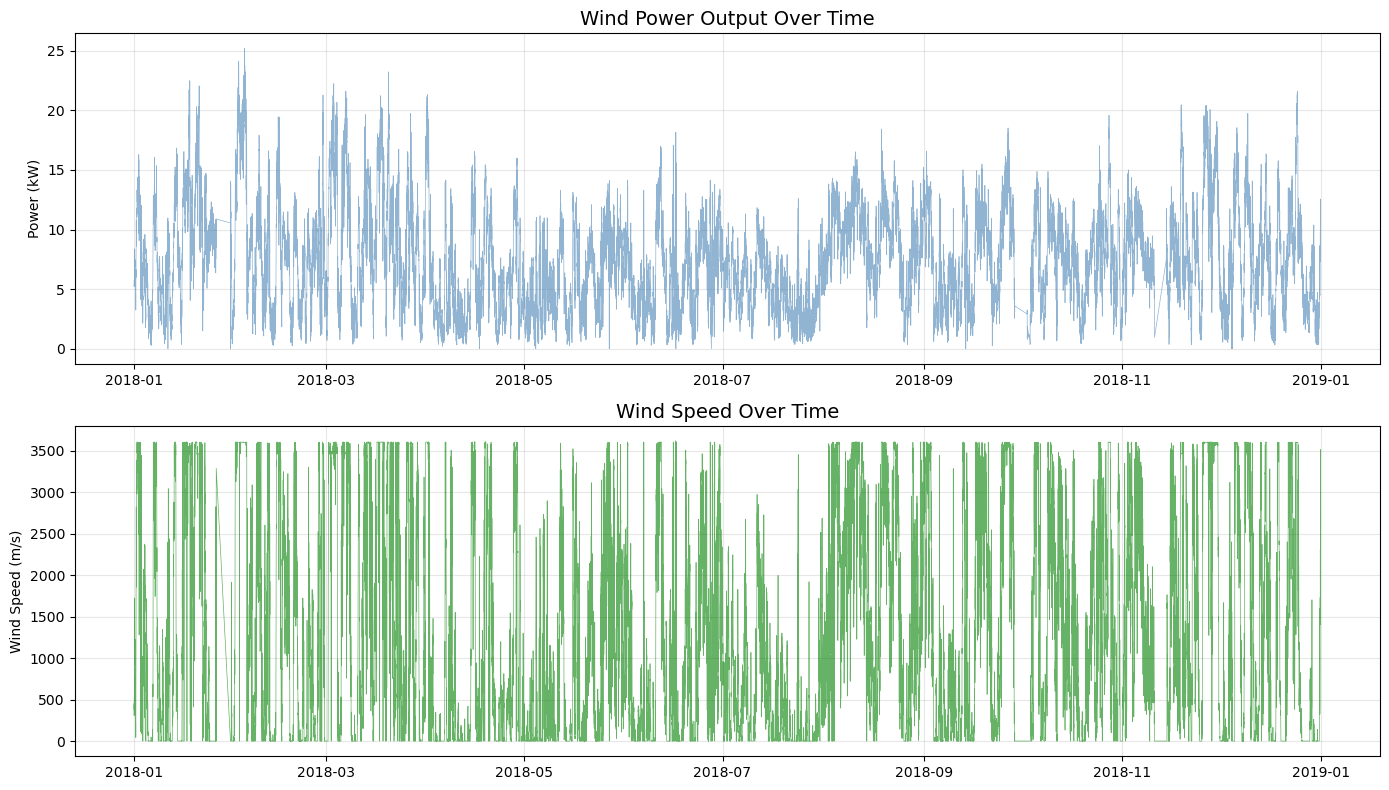

In [6]:
# Plot 1: Power output over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df['datetime'], df['power'], alpha=0.6, color='steelblue', linewidth=0.5)
axes[0].set_title('Wind Power Output Over Time', fontsize=14)
axes[0].set_ylabel('Power (kW)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['datetime'], df['wind_speed'], alpha=0.6, color='green', linewidth=0.5)
axes[1].set_title('Wind Speed Over Time', fontsize=14)
axes[1].set_ylabel('Wind Speed (m/s)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('time_series_plot.png', dpi=150, bbox_inches='tight')
plt.show()

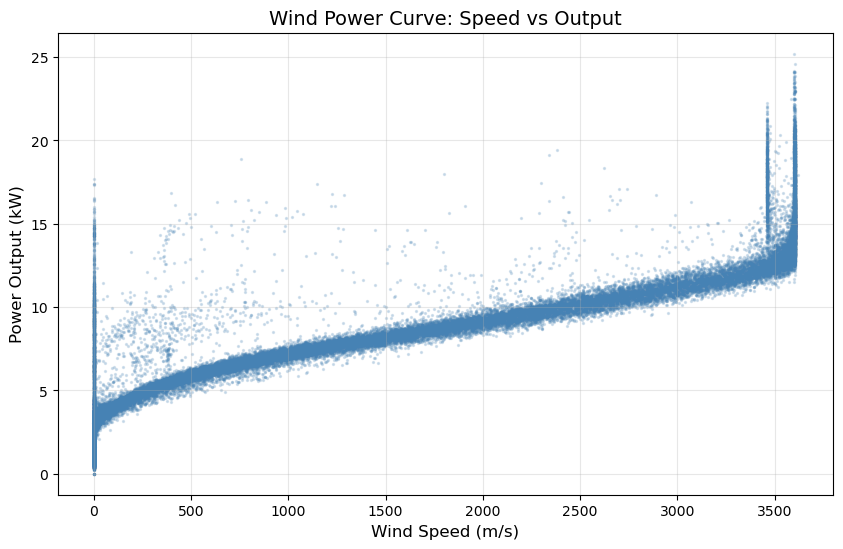

In [7]:
# Plot 2: Wind speed vs Power (the power curve)
plt.figure(figsize=(10, 6))
plt.scatter(df['wind_speed'], df['power'], alpha=0.2, s=2, color='steelblue')
plt.xlabel('Wind Speed (m/s)', fontsize=12)
plt.ylabel('Power Output (kW)', fontsize=12)
plt.title('Wind Power Curve: Speed vs Output', fontsize=14)
plt.grid(True, alpha=0.3)
plt.savefig('power_curve.png', dpi=150, bbox_inches='tight')
plt.show()
# NOTE: This non-linear S-curve relationship is exactly why MLP will outperform Linear Regression

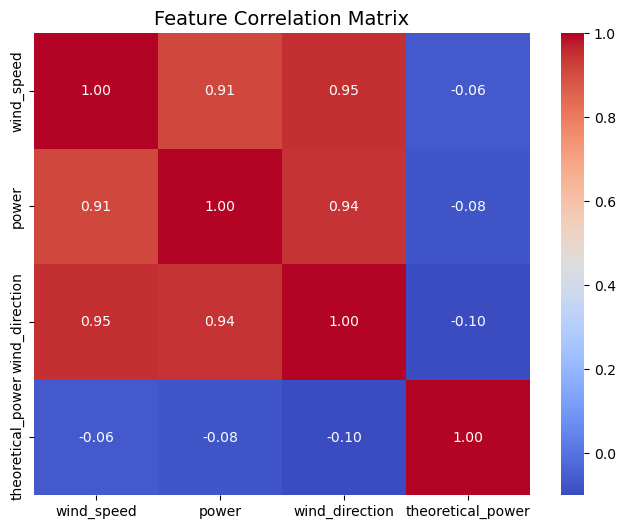

In [8]:
# Plot 3: Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop('datetime', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=14)
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

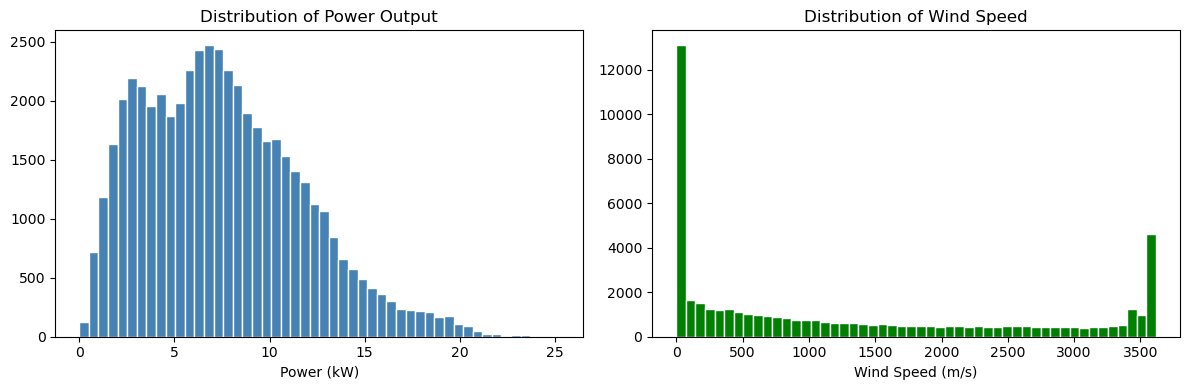

In [9]:
# Plot 4: Distribution of power output
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['power'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Power Output')
axes[0].set_xlabel('Power (kW)')

axes[1].hist(df['wind_speed'], bins=50, color='green', edgecolor='white')
axes[1].set_title('Distribution of Wind Speed')
axes[1].set_xlabel('Wind Speed (m/s)')

plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Feature Engineering

In [10]:
# Handle missing values
df = df.set_index('datetime') # set datetime as index first
df = df.interpolate(method='linear') # linear interpolation on numeric cols only
df = df.ffill().bfill()  # edge cases
df = df.reset_index() # bring datetime back as column

print('Missing values after imputation:', df.isnull().sum().sum())

Missing values after imputation: 0


In [11]:
# Physics-inspired features
df['wind_speed_sq']   = df['wind_speed'] ** 2
df['wind_speed_cube'] = df['wind_speed'] ** 3

# Temporal features
df['hour']    = df['datetime'].dt.hour
df['month']   = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.weekday
df['season']  = df['month'].map({12:0,1:0,2:0, 3:1,4:1,5:1, 6:2,7:2,8:2, 9:3,10:3,11:3})

# Lag features (capture recent dynamics)
for lag in [1, 2, 4, 6]:
    df[f'wind_speed_lag_{lag}'] = df['wind_speed'].shift(lag)
    df[f'power_lag_{lag}']      = df['power'].shift(lag)

# Rolling statistics
df['wind_speed_roll_mean_6']  = df['wind_speed'].rolling(6).mean()
df['wind_speed_roll_std_6']   = df['wind_speed'].rolling(6).std()
df['wind_speed_roll_mean_24'] = df['wind_speed'].rolling(24).mean()

# Wind direction features (cyclical encoding)
df['wind_dir_sin'] = np.sin(np.radians(df['wind_direction']))
df['wind_dir_cos'] = np.cos(np.radians(df['wind_direction']))

# Drop NaNs created by lag/rolling
df = df.dropna().reset_index(drop=True)

print(f'Final dataset shape: {df.shape}')
print(f'Features created: {df.shape[1] - 2} (excluding datetime and target)')

Final dataset shape: (50507, 24)
Features created: 22 (excluding datetime and target)


---
## 4. Data Preparation & Train/Test Split

In [12]:
# Define features and target
feature_cols = [
    'wind_speed', 'wind_speed_sq', 'wind_speed_cube',
    'wind_dir_sin', 'wind_dir_cos',
    'hour', 'month', 'weekday', 'season',
    'wind_speed_lag_1', 'wind_speed_lag_2', 'wind_speed_lag_4', 'wind_speed_lag_6',
    'power_lag_1', 'power_lag_2', 'power_lag_4', 'power_lag_6',
    'wind_speed_roll_mean_6', 'wind_speed_roll_std_6', 'wind_speed_roll_mean_24'
]

X = df[feature_cols].values
y = df['power'].values

# Temporal split: 80% train, 20% test
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]} samples')
print(f'Test size:  {X_test.shape[0]} samples')
print(f'Number of features: {X_train.shape[1]}')

Train size: 40405 samples
Test size:  10102 samples
Number of features: 20


---
## 5. Baseline Models

In [13]:
# Helper function for evaluation metrics
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'--- {model_name} ---')
    print(f'  RMSE : {rmse:.2f} kW')
    print(f'  MAE  : {mae:.2f} kW')
    print(f'  R²   : {r2:.4f}')
    return {'model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

In [14]:
results = []

# Baseline 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
results.append(evaluate_model(y_test, y_pred_lr, 'Linear Regression'))

print()

# Baseline 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
results.append(evaluate_model(y_test, y_pred_rf, 'Random Forest'))

--- Linear Regression ---
  RMSE : 0.51 kW
  MAE  : 0.33 kW
  R²   : 0.9858

--- Random Forest ---
  RMSE : 0.46 kW
  MAE  : 0.26 kW
  R²   : 0.9882


---
## 6. MLP Neural Network (PyTorch)

In [15]:
class WindPowerMLP(nn.Module):
    def __init__(self, input_dim):
        super(WindPowerMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)

# Instantiate model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = WindPowerMLP(input_dim=X_train_scaled.shape[1]).to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

WindPowerMLP(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): ReLU()
    (14): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 49,537


In [16]:
# Prepare DataLoaders
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled  = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.FloatTensor(y_train_scaled).to(device)
X_test_tensor  = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor  = torch.FloatTensor(y_test_scaled).to(device)

# Validation split from training set (last 10%)
val_split = int(len(X_train_tensor) * 0.9)
train_dataset = TensorDataset(X_train_tensor[:val_split], y_train_tensor[:val_split])
val_dataset   = TensorDataset(X_train_tensor[val_split:], y_train_tensor[val_split:])

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=False)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')

Train batches: 143
Val batches:   64


In [17]:
# Training loop with early stopping
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=8, factor=0.5)

criterion  = nn.MSELoss()

EPOCHS   = 300
PATIENCE = 20

best_val_loss = float('inf')
patience_cnt  = 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # Training
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            preds    = model(X_batch)
            val_loss += criterion(preds, y_batch).item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_cnt  = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d} | Train Loss: {train_loss:.2f} | Val Loss: {val_loss:.2f}')

# Load best model
model.load_state_dict(torch.load('best_model.pt'))

Epoch  10 | Train Loss: 0.15 | Val Loss: 0.05
Epoch  20 | Train Loss: 0.10 | Val Loss: 0.03
Epoch  30 | Train Loss: 0.09 | Val Loss: 0.03
Epoch  40 | Train Loss: 0.08 | Val Loss: 0.02
Epoch  50 | Train Loss: 0.07 | Val Loss: 0.02
Epoch  60 | Train Loss: 0.07 | Val Loss: 0.02
Epoch  70 | Train Loss: 0.07 | Val Loss: 0.02
Epoch  80 | Train Loss: 0.07 | Val Loss: 0.02
Epoch  90 | Train Loss: 0.07 | Val Loss: 0.02
Epoch 100 | Train Loss: 0.07 | Val Loss: 0.02
Epoch 110 | Train Loss: 0.07 | Val Loss: 0.02
Epoch 120 | Train Loss: 0.07 | Val Loss: 0.02
Epoch 130 | Train Loss: 0.07 | Val Loss: 0.02
Epoch 140 | Train Loss: 0.07 | Val Loss: 0.02
Epoch 150 | Train Loss: 0.07 | Val Loss: 0.02
Early stopping at epoch 156


<All keys matched successfully>

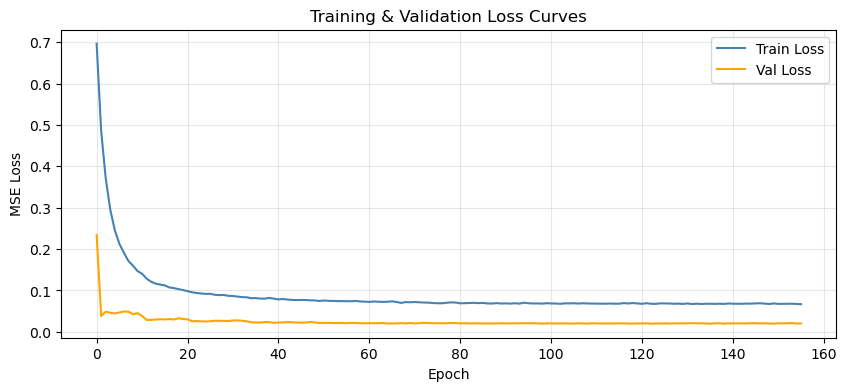

In [18]:
# Plot training curves
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses,   label='Val Loss',   color='orange')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Evaluate MLP on test set
model.eval()
with torch.no_grad():
    y_pred_mlp_scaled = model(X_test_tensor).cpu().numpy()

y_pred_mlp = scaler_y.inverse_transform(y_pred_mlp_scaled.reshape(-1, 1)).flatten()
results.append(evaluate_model(y_test, y_pred_mlp, 'MLP (PyTorch)'))

--- MLP (PyTorch) ---
  RMSE : 0.89 kW
  MAE  : 0.61 kW
  R²   : 0.9568


---
## 7. Results Comparison

In [20]:
# Summary table
results_df = pd.DataFrame(results)
print('\n=== Model Comparison ===')
print(results_df.to_string(index=False))


=== Model Comparison ===
            model     RMSE      MAE       R2
Linear Regression 0.509761 0.325057 0.985827
    Random Forest 0.464443 0.259290 0.988235
    MLP (PyTorch) 0.889519 0.605514 0.956843


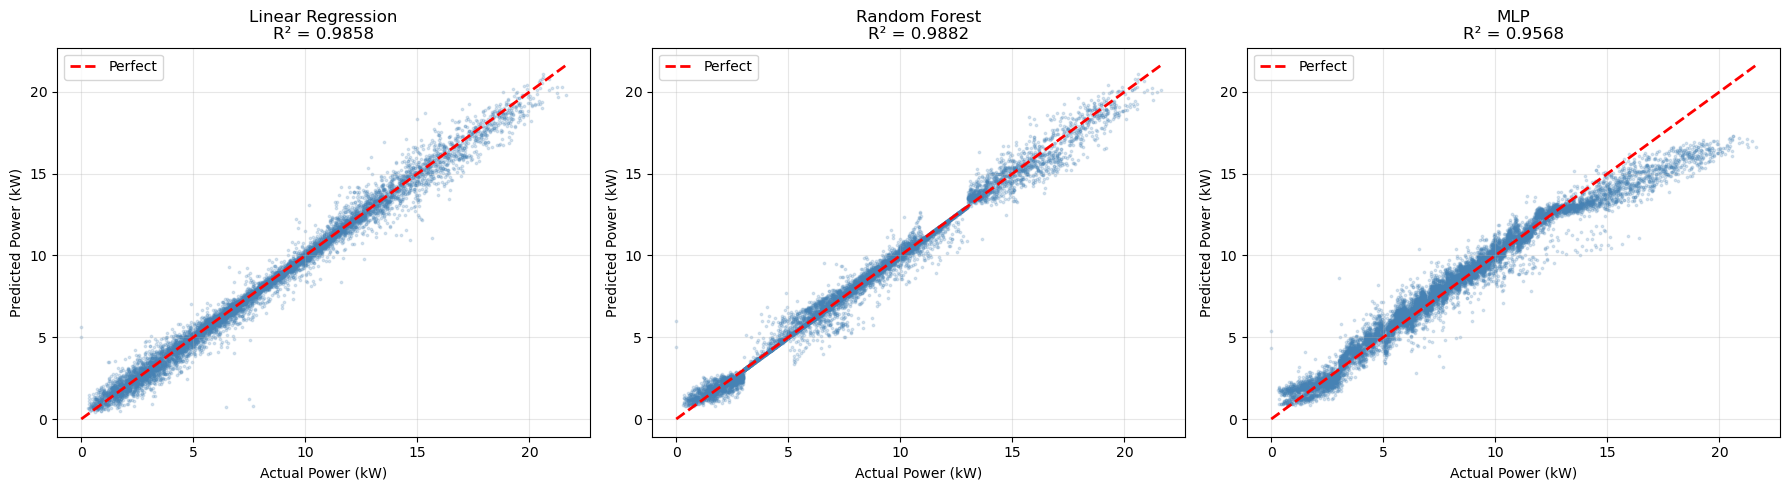

In [21]:
# Plot: Predicted vs Actual for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_preds = [('Linear Regression', y_pred_lr), ('Random Forest', y_pred_rf), ('MLP', y_pred_mlp)]

for ax, (name, preds) in zip(axes, models_preds):
    ax.scatter(y_test, preds, alpha=0.2, s=3, color='steelblue')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect')
    ax.set_xlabel('Actual Power (kW)')
    ax.set_ylabel('Predicted Power (kW)')
    ax.set_title(f'{name}\nR² = {r2_score(y_test, preds):.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

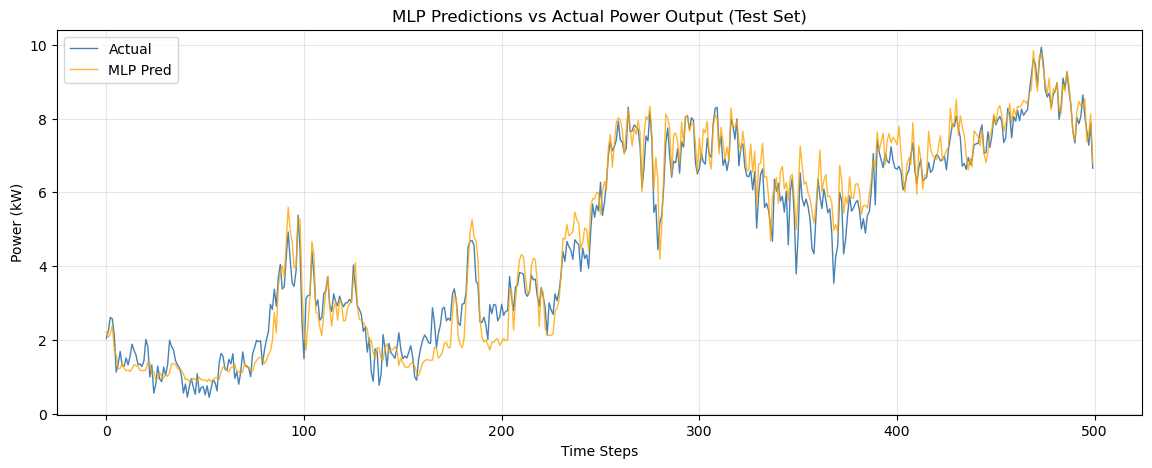

In [22]:
# Plot: Time series of predictions vs actuals
n_plot = 500  # plot first 500 test points for readability
plt.figure(figsize=(14, 5))
plt.plot(y_test[:n_plot],     label='Actual',    color='steelblue', linewidth=1)
plt.plot(y_pred_mlp[:n_plot], label='MLP Pred',  color='orange',    linewidth=1, alpha=0.8)
plt.xlabel('Time Steps')
plt.ylabel('Power (kW)')
plt.title('MLP Predictions vs Actual Power Output (Test Set)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('predictions_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. SHAP Values — Model Interpretability

In [23]:
# SHAP explanation using a background sample
background = X_train_scaled[:500]  # background dataset for SHAP
background_tensor = torch.FloatTensor(background).to(device)

# Wrapper for SHAP compatibility
def model_predict(x):
    model.eval()
    with torch.no_grad():
        return model(torch.FloatTensor(x).to(device)).cpu().numpy()

explainer   = shap.KernelExplainer(model_predict, background)
shap_values = explainer.shap_values(X_test_scaled[:200], nsamples=100)

Using 500 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/200 [00:00<?, ?it/s]

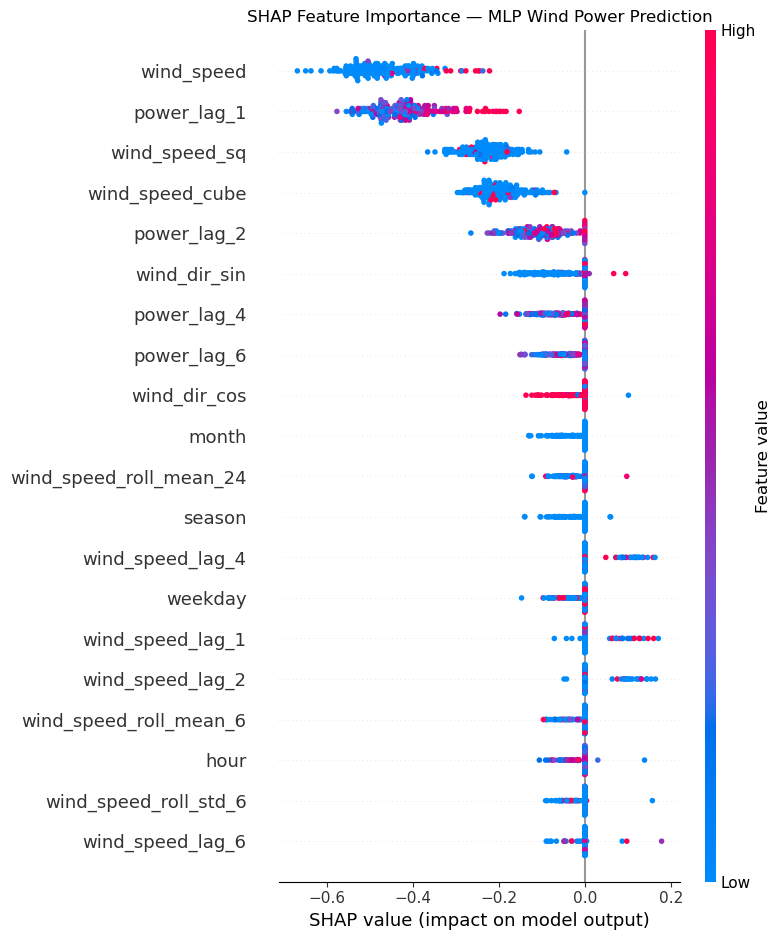

In [24]:
# SHAP Summary Plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_scaled[:200], feature_names=feature_cols, show=False)
plt.title('SHAP Feature Importance — MLP Wind Power Prediction')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

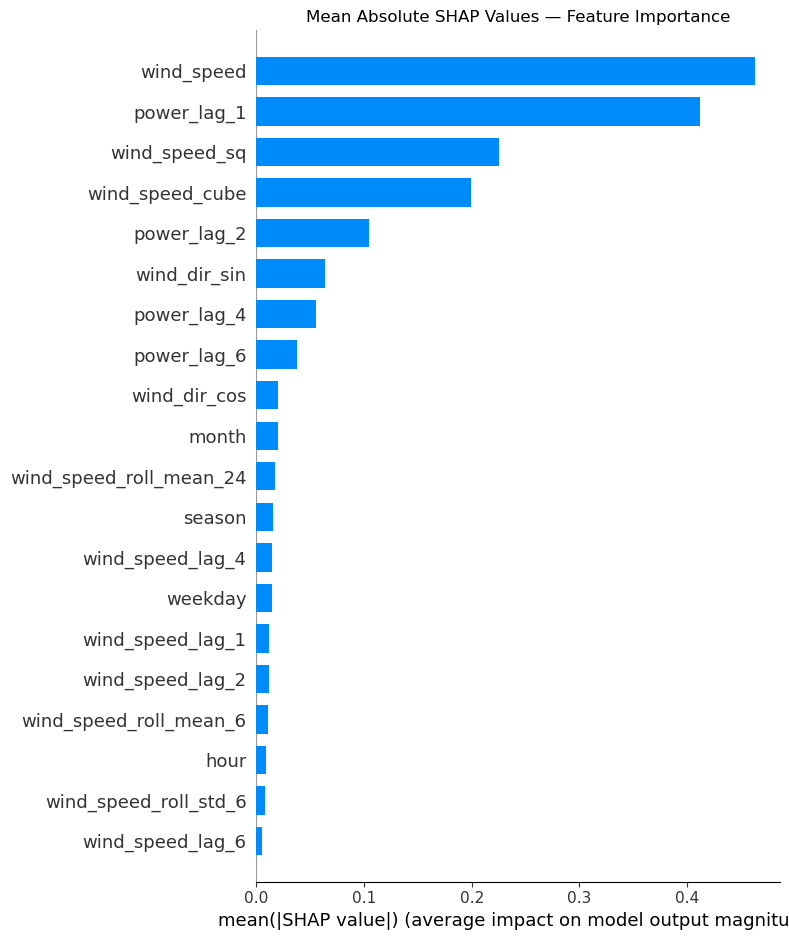

In [25]:
# SHAP Bar Plot (mean absolute importance)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled[:200], feature_names=feature_cols, plot_type='bar', show=False)
plt.title('Mean Absolute SHAP Values — Feature Importance')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Error Analysis

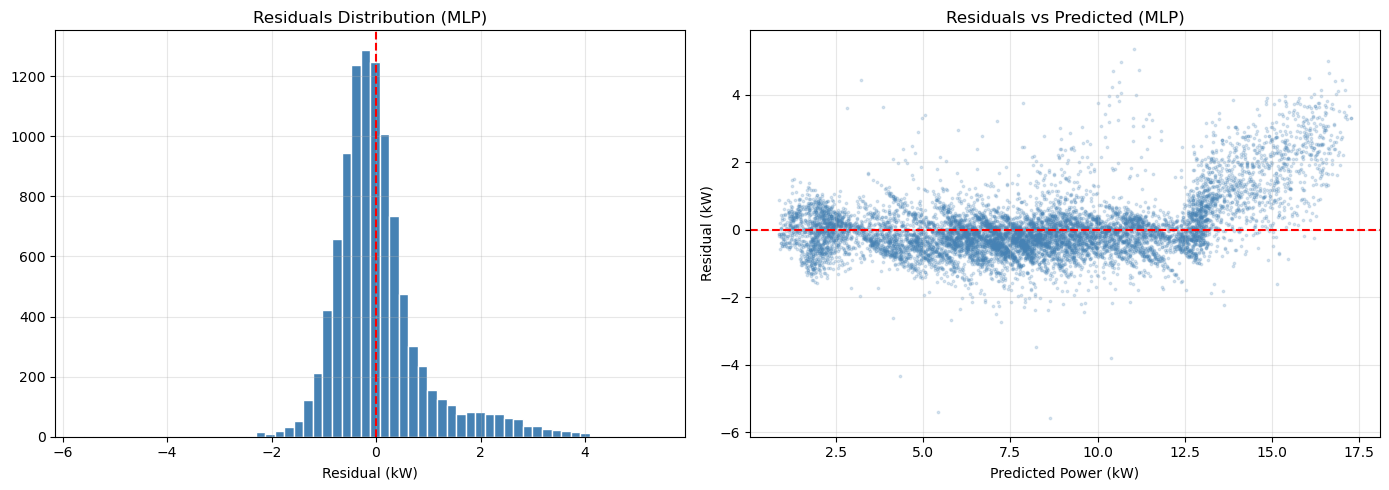

Mean residual: 0.04 kW
Std residual:  0.89 kW


In [26]:
# Residuals analysis (MLP)
residuals = y_test - y_pred_mlp

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals distribution
axes[0].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residuals Distribution (MLP)')
axes[0].set_xlabel('Residual (kW)')
axes[0].grid(True, alpha=0.3)

# Residuals vs Predicted
axes[1].scatter(y_pred_mlp, residuals, alpha=0.2, s=3, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted (MLP)')
axes[1].set_xlabel('Predicted Power (kW)')
axes[1].set_ylabel('Residual (kW)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean residual: {residuals.mean():.2f} kW')
print(f'Std residual:  {residuals.std():.2f} kW')

---
## 10. SUMMARY

In [27]:
print('FINAL RESULTS SUMMARY')
print(results_df.sort_values('RMSE').to_string(index=False))
best = results_df.loc[results_df['RMSE'].idxmin(), 'model']
print(f'\nBest model: {best}')

FINAL RESULTS SUMMARY
            model     RMSE      MAE       R2
    Random Forest 0.464443 0.259290 0.988235
Linear Regression 0.509761 0.325057 0.985827
    MLP (PyTorch) 0.889519 0.605514 0.956843

Best model: Random Forest
